## Load Data & Perform Initial Inspection

In [1]:
import pandas as pd

df = pd.read_csv("/workspaces/final-project-abshire/data/pitch_2024_relevant.csv")

# Basic checks
print(df.shape)       # rows, columns
print(df.columns)     # column names
df.head()             # first 5 rows
df.info()             # datatypes & null counts
df.describe()         # summary stats for numeric columns

# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")
# 0 duplicate rows, that's huge

# Percentage of missing values per column
missing_percent = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_percent)

# Unique counts for all object columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

(827825, 20)
Index(['Unnamed: 0', 'batter', 'player_name', 'game_date', 'stand', 'p_throws',
       'pitch_type', 'effective_speed', 'pfx_x', 'pfx_z', 'plate_x', 'plate_z',
       'zone', 'description', 'launch_speed', 'launch_angle', 'hc_x', 'hc_y',
       'if_fielding_alignment', 'events'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827825 entries, 0 to 827824
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             827825 non-null  int64  
 1   batter                 827825 non-null  int64  
 2   player_name            827825 non-null  object 
 3   game_date              827825 non-null  object 
 4   stand                  827825 non-null  object 
 5   p_throws               827825 non-null  object 
 6   pitch_type             827369 non-null  object 
 7   effective_speed        826291 non-null  float64
 8   pfx_x                  827369 non-null

### Comparing 'description' (pitch-level) and 'events' (outcome-level)

In [2]:
# Target variable could be a few things... 
# Let's start with looking at description and events

print("Description value counts:")
print(df['description'].value_counts(dropna=False))

print("\nEvents value counts:")
print(df['events'].value_counts(dropna=False))

Description value counts:
description
ball                       275067
foul                       150137
hit_into_play              145226
called_strike              135636
swinging_strike             87075
blocked_ball                17423
foul_tip                     8586
swinging_strike_blocked      4591
hit_by_pitch                 2337
foul_bunt                    1439
missed_bunt                   229
pitchout                       62
bunt_foul_tip                  17
Name: count, dtype: int64

Events value counts:
events
NaN                          615128
field_out                     86474
strikeout                     47788
single                        30198
walk                          16736
double                         9080
home_run                       6299
force_out                      4068
grounded_into_double_play      3754
hit_by_pitch                   2337
sac_fly                        1445
field_error                    1319
triple                          8

### Seeing all unique pitch types

In [3]:
df['pitch_type'].value_counts(dropna=False)

pitch_type
FF     263254
SI     130658
SL     126226
CH      84128
FC      67796
ST      55962
CU      51952
FS      25912
KC      14748
SV       3804
KN       1226
FA        645
EP        607
NaN       456
FO        174
SC        153
PO         62
CS         62
Name: count, dtype: int64

### New Data Frame (df_hits) and merging player names

In [4]:
import pandas as pd

# Load data
pitch_df = pd.read_csv('/workspaces/final-project-abshire/data/pitch_2024_relevant.csv')
player_ids_df = pd.read_csv('/workspaces/final-project-abshire/data/player_ids.csv')

# Prepare player IDs
player_ids_sub = player_ids_df[['MLBAMID', 'Name']].rename(columns={'Name': 'batter_name'})

# Merge on batter and MLBAMID
df_hits = pitch_df.merge(player_ids_sub, left_on='batter', right_on='MLBAMID', how='left')
df_hits = df_hits.drop(columns=['MLBAMID'])
df_hits = df_hits.rename(columns={'player_name': 'pitcher_name'})

# Filter to hitting events only
hitting_events = ['single', 'double', 'triple', 'home_run']
df_hits = df_hits[df_hits['events'].isin(hitting_events)].copy()

# Now define your pitch_type_map
pitch_type_map = {
    'FF': 'Fastball',  # Four-Seam
    'FA': 'Fastball',  # General Fastball
    'FT': 'Fastball',  # Two-Seam
    'SI': 'Fastball',  # Sinker
    'FS': 'Fastball',  # Split Finger
    'SL': 'Slider',    # Slider
    'SV': 'Slider',    # Slurve
    'ST': 'Curveball', # Sweeper
    'CU': 'Curveball', # Curveball
    'KC': 'Curveball', # Knuckle Curve
    'CH': 'Changeup',  # Change Up
    'FO': 'Changeup',  # Fork Ball
    'EP': 'Changeup',  # Eephus
    'FC': 'Fastball',  # Cutter
    'KN': 'Knuckleball', # Knuckleball
    'SC': 'Other',     # Screwball
    'CS': 'Other',     # Slow Curve
    'PO': 'Other',     # Pitch Out?
    None: 'Unknown',   # or np.nan mapped to 'Unknown'
    'NaN': 'Unknown'   # if string 'NaN'
}

# Map pitch_type to pitch_group column
df_hits['pitch_group'] = df_hits['pitch_type'].map(pitch_type_map).fillna('Unknown')

print(df_hits.head())

     Unnamed: 0  batter     pitcher_name   game_date stand p_throws  \
13           13  663898    Ginkel, Kevin  2024-03-31     R        R   
38           38  678662   Thompson, Ryan  2024-03-31     R        R   
57           57  595909   McGough, Scott  2024-03-31     L        R   
81           81  666971    Feltner, Ryan  2024-03-31     R        R   
112         112  607732  Pfaadt, Brandon  2024-03-31     R        R   

    pitch_type  effective_speed  pfx_x  pfx_z  ...  zone    description  \
13          FF             96.6  -0.72   1.19  ...   6.0  hit_into_play   
38          SI             90.8  -1.04  -0.67  ...   5.0  hit_into_play   
57          FF             93.1  -0.66   1.36  ...   4.0  hit_into_play   
81          FF             97.3  -0.53   1.15  ...   4.0  hit_into_play   
112         ST             84.5   0.90   0.62  ...   6.0  hit_into_play   

     launch_speed launch_angle    hc_x    hc_y  if_fielding_alignment  events  \
13           96.8         11.0  146.19   

### Launch Speed & Angle Patterns by Hit Type

         launch_speed                                                    \
                count        mean        std   min    25%    50%    75%   
events                                                                    
double         9121.0   97.858338  10.221809  40.4   93.7  100.2  104.8   
home_run       6356.0  104.339475   4.353653  86.5  101.5  104.5  107.2   
single        30243.0   89.798800  15.414024   8.8   80.4   93.6  101.4   
triple          832.0   98.619471   7.431344  64.4   94.8  100.3  103.6   

                launch_angle                                                \
            max        count       mean        std   min   25%   50%   75%   
events                                                                       
double    121.5       9121.0  16.572963  10.622281 -44.0  12.0  17.0  22.0   
home_run  119.9       6356.0  28.735211   5.161641  14.0  25.0  28.0  32.0   
single    120.4      30261.0   5.913156  18.440884 -88.0   0.0   9.0  15.0   
triple

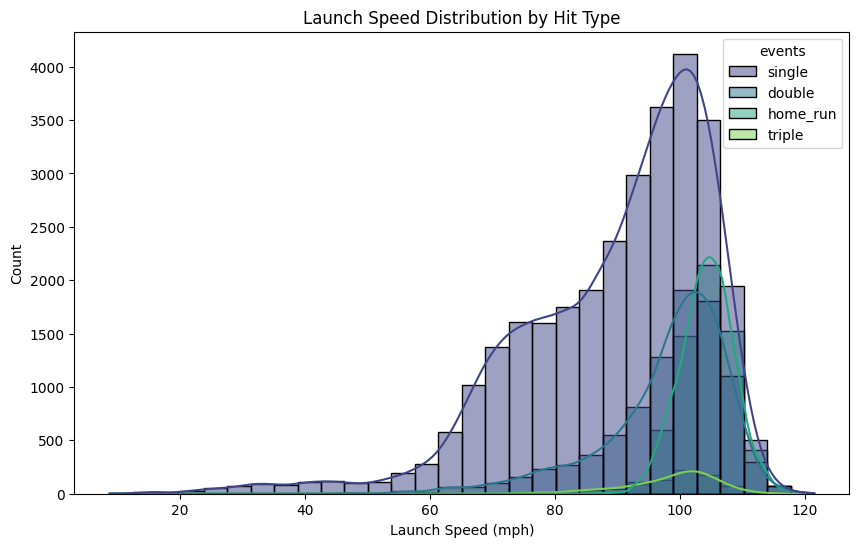

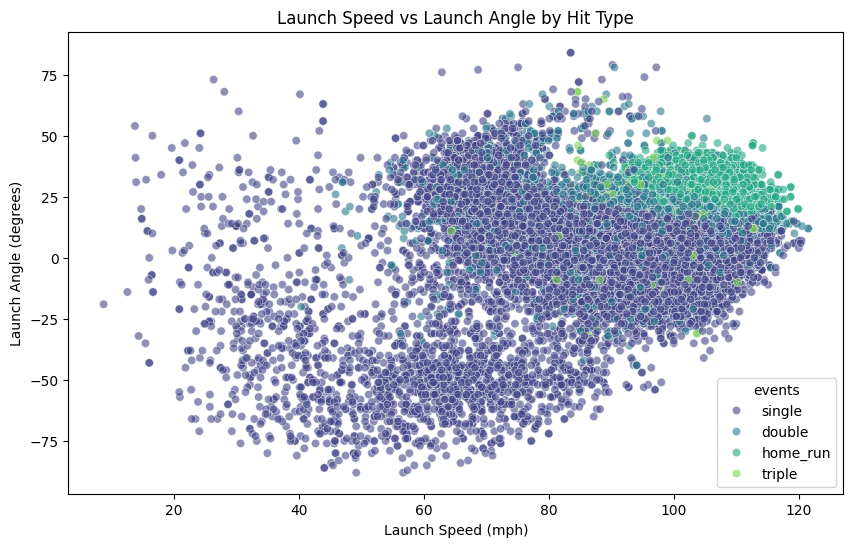

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Summary stats of launch speed and launch angle by hit type
summary_stats = df_hits.groupby('events')[['launch_speed', 'launch_angle']].describe()
print(summary_stats)

# Plot distribution of launch speed by hit type
plt.figure(figsize=(10, 6))
sns.histplot(data=df_hits, x='launch_speed', hue='events', bins=30, kde=True, palette='viridis')
plt.title('Launch Speed Distribution by Hit Type')
plt.xlabel('Launch Speed (mph)')
plt.ylabel('Count')
plt.show()

# Scatterplot of launch speed vs launch angle by hit type
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_hits, x='launch_speed', y='launch_angle', hue='events', alpha=0.6, palette='viridis')
plt.title('Launch Speed vs Launch Angle by Hit Type')
plt.xlabel('Launch Speed (mph)')
plt.ylabel('Launch Angle (degrees)')
plt.show()


### Sweet Spot Scatter Plot

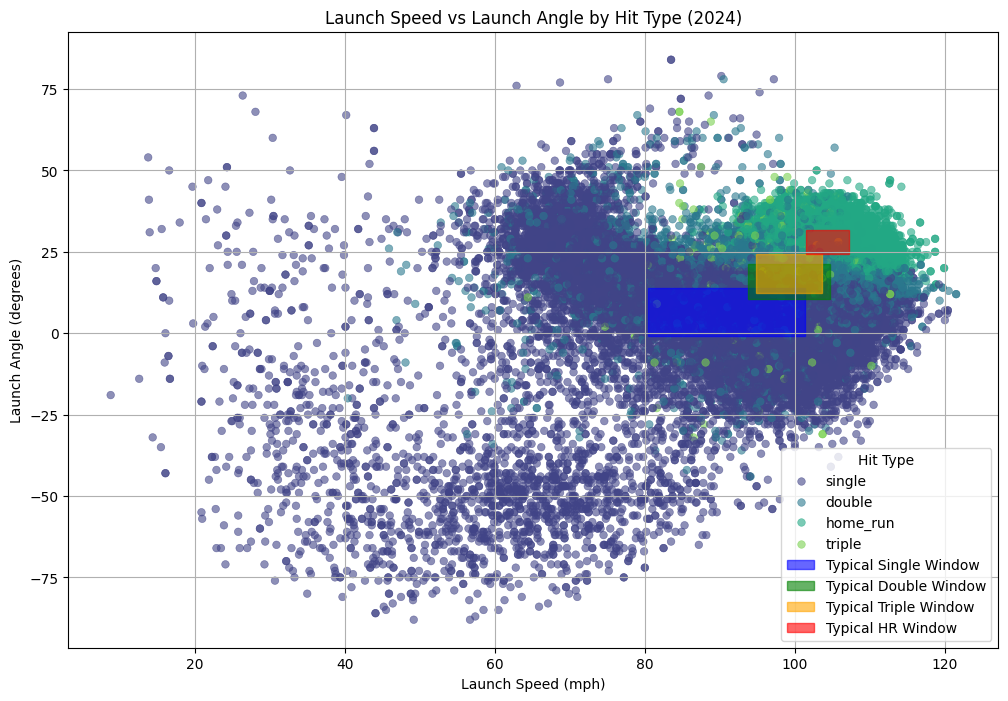

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

# Scatterplot of launch speed vs launch angle by hit type
sns.scatterplot(
    data=df_hits, 
    x='launch_speed', 
    y='launch_angle', 
    hue='events', 
    alpha=0.6, 
    palette='viridis',
    edgecolor=None,
    s=30
)

# Add shaded boxes for typical launch windows (approximate)

# Singles
plt.axvspan(80.4, 101.4, ymin=(1 + 90)/180, ymax=(15 + 90)/180, color='blue', alpha=0.6, label='Typical Single Window')

# Doubles
plt.axvspan(93.7, 104.7, ymin=(12 + 90)/180, ymax=(22 + 90)/180, color='green', alpha=0.6, label='Typical Double Window')

# Triples
plt.axvspan(94.8, 103.6, ymin=(13.75 + 90)/180, ymax=(25 + 90)/180, color='orange', alpha=0.6, label='Typical Triple Window')

# Home Runs
plt.axvspan(101.5, 107.2, ymin=(25 + 90)/180, ymax=(32 + 90)/180, color='red', alpha=0.6, label='Typical HR Window')

plt.title('Launch Speed vs Launch Angle by Hit Type (2024)')
plt.xlabel('Launch Speed (mph)')
plt.ylabel('Launch Angle (degrees)')
plt.legend(title='Hit Type')
plt.grid(True)
plt.show()


### Launch Metrics Summary by Statcast Zone

In [7]:
zone_summary = (
    df_hits
    .groupby('zone')[['launch_speed']]
    .agg(['count', 'mean', 'std', 'median'])
    .round(2)
)

zone_summary

launch_speed                     
            count   mean    std median
zone                                  
1.0          2131  91.52  14.63   96.0
2.0          3310  96.43  12.65   99.8
3.0          2023  92.24  15.22   97.4
4.0          5170  94.05  13.83   98.0
5.0          8054  98.12  11.71  101.2
6.0          5085  94.48  13.76   98.8
7.0          3368  94.39  13.18   97.8
8.0          5885  97.44  12.14  100.8
9.0          3747  92.73  13.88   96.5
11.0         1371  84.30  17.11   88.1
12.0         1354  85.24  17.17   89.4
13.0         2255  85.43  15.41   86.9
14.0         2799  83.39  15.66   83.8

### Launch Speed and Angle Distributions by Zone

/tmp/ipykernel_5094/1802878546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hits, x='zone', y='launch_speed', ax=axes[0], palette='viridis')


/tmp/ipykernel_5094/1802878546.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_hits, x='zone', y='launch_angle', ax=axes[1], palette='magma')


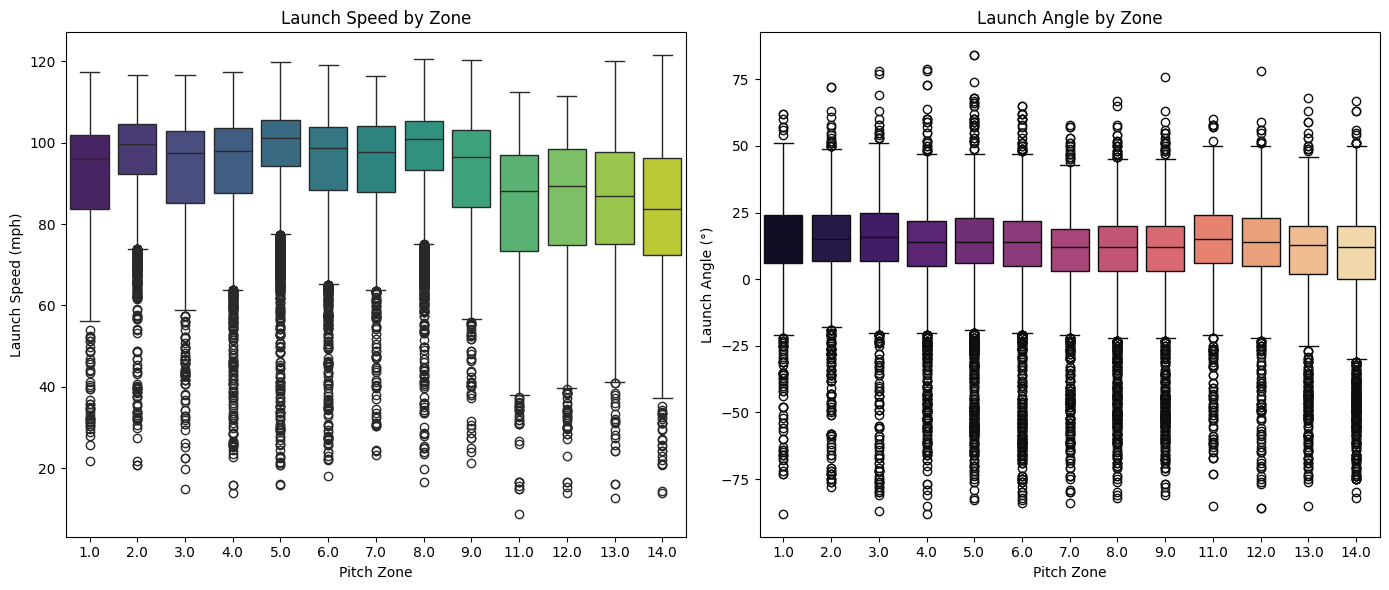

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for launch speed by zone
sns.boxplot(data=df_hits, x='zone', y='launch_speed', ax=axes[0], palette='viridis')
axes[0].set_title('Launch Speed by Zone')
axes[0].set_xlabel('Pitch Zone')
axes[0].set_ylabel('Launch Speed (mph)')

# Boxplot for launch angle by zone
sns.boxplot(data=df_hits, x='zone', y='launch_angle', ax=axes[1], palette='magma')
axes[1].set_title('Launch Angle by Zone')
axes[1].set_xlabel('Pitch Zone')
axes[1].set_ylabel('Launch Angle (°)')

plt.tight_layout()
plt.show()


### Heatmap of Mean Launch Speed by Statcast Zone

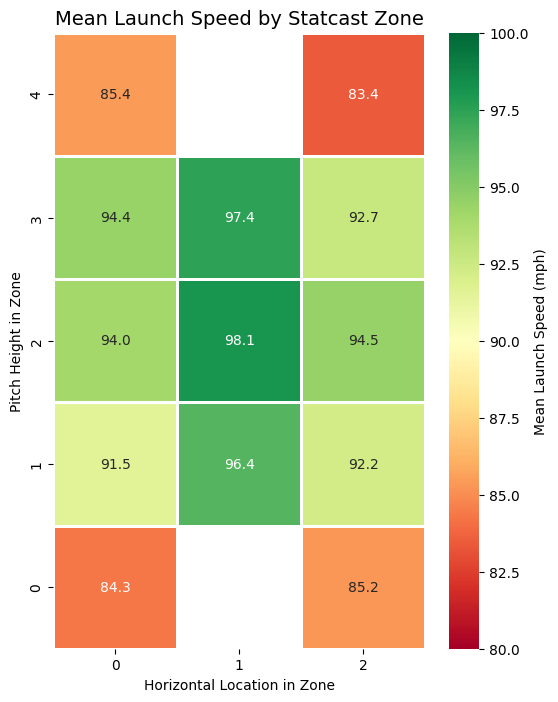

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example: your summarized data in a DataFrame
zone_data = {
    'zone': [1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14],
    'mean_launch_speed': [91.52, 96.43, 92.24, 94.05, 98.12, 94.48, 94.39, 97.44, 92.73, 84.30, 85.24, 85.43, 83.39]
}
df_zone = pd.DataFrame(zone_data)

# Strike zone layout mapping
zone_grid = pd.DataFrame([
    [11, None, 12],
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [13, None, 14] 
])

# Map mean launch speed to the grid
heatmap_values = zone_grid.replace(
    {z: df_zone.set_index('zone')['mean_launch_speed'].get(z) for z in df_zone['zone']}
)

# Plot
plt.figure(figsize=(6,8))
sns.heatmap(
    heatmap_values.astype(float), 
    annot=True, fmt=".1f", cmap="RdYlGn", 
    linewidths=1, cbar_kws={'label': 'Mean Launch Speed (mph)'},
    vmin=80, vmax=100
)
plt.title('Mean Launch Speed by Statcast Zone', fontsize=14)
plt.ylabel('Pitch Height in Zone')
plt.xlabel('Horizontal Location in Zone')
plt.gca().invert_yaxis()
plt.show()

### Hit Outcome Rates by Zone (Stacked Bar Chart)

events  single  double  triple  home_run
zone                                    
1.0      66.85   17.21    1.27     14.67
2.0      58.19   19.67    2.21     19.94
3.0      62.24   19.50    1.78     16.49
4.0      63.50   21.01    1.47     14.02
5.0      57.25   21.21    2.11     19.43
6.0      64.20   19.25    2.18     14.36
7.0      66.06   21.63    1.36     10.95
8.0      61.70   22.54    1.80     13.95
9.0      70.35   17.54    2.32      9.78
11.0     72.34   17.76    0.66      9.24
12.0     74.69   16.09    1.85      7.38
13.0     74.63   19.21    0.66      5.49
14.0     82.57   11.42    1.81      4.20


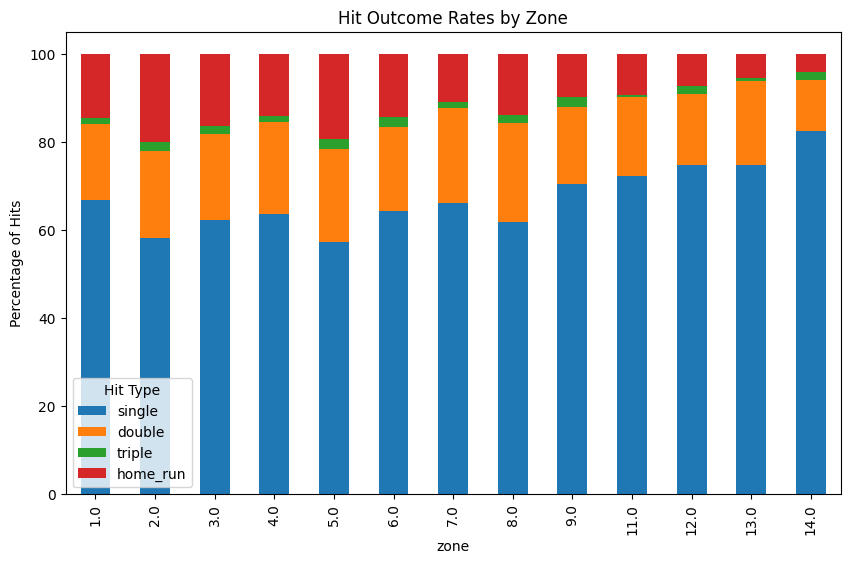

In [10]:
# Count total hits per zone
total_per_zone = df_hits.groupby('zone').size()

# Count each hit type per zone
hits_per_zone = df_hits.groupby(['zone', 'events']).size().unstack(fill_value=0)

# Convert to percentage of hits in that zone
hit_rates = hits_per_zone.div(total_per_zone, axis=0) * 100

# Optional: order the columns consistently
hit_rates = hit_rates[['single', 'double', 'triple', 'home_run']]

print(hit_rates.round(2))

# Plot stacked bar chart
hit_rates.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Percentage of Hits")
plt.title("Hit Outcome Rates by Zone")
plt.legend(title="Hit Type")
plt.show()


### Heatmap of Zones by Pitch

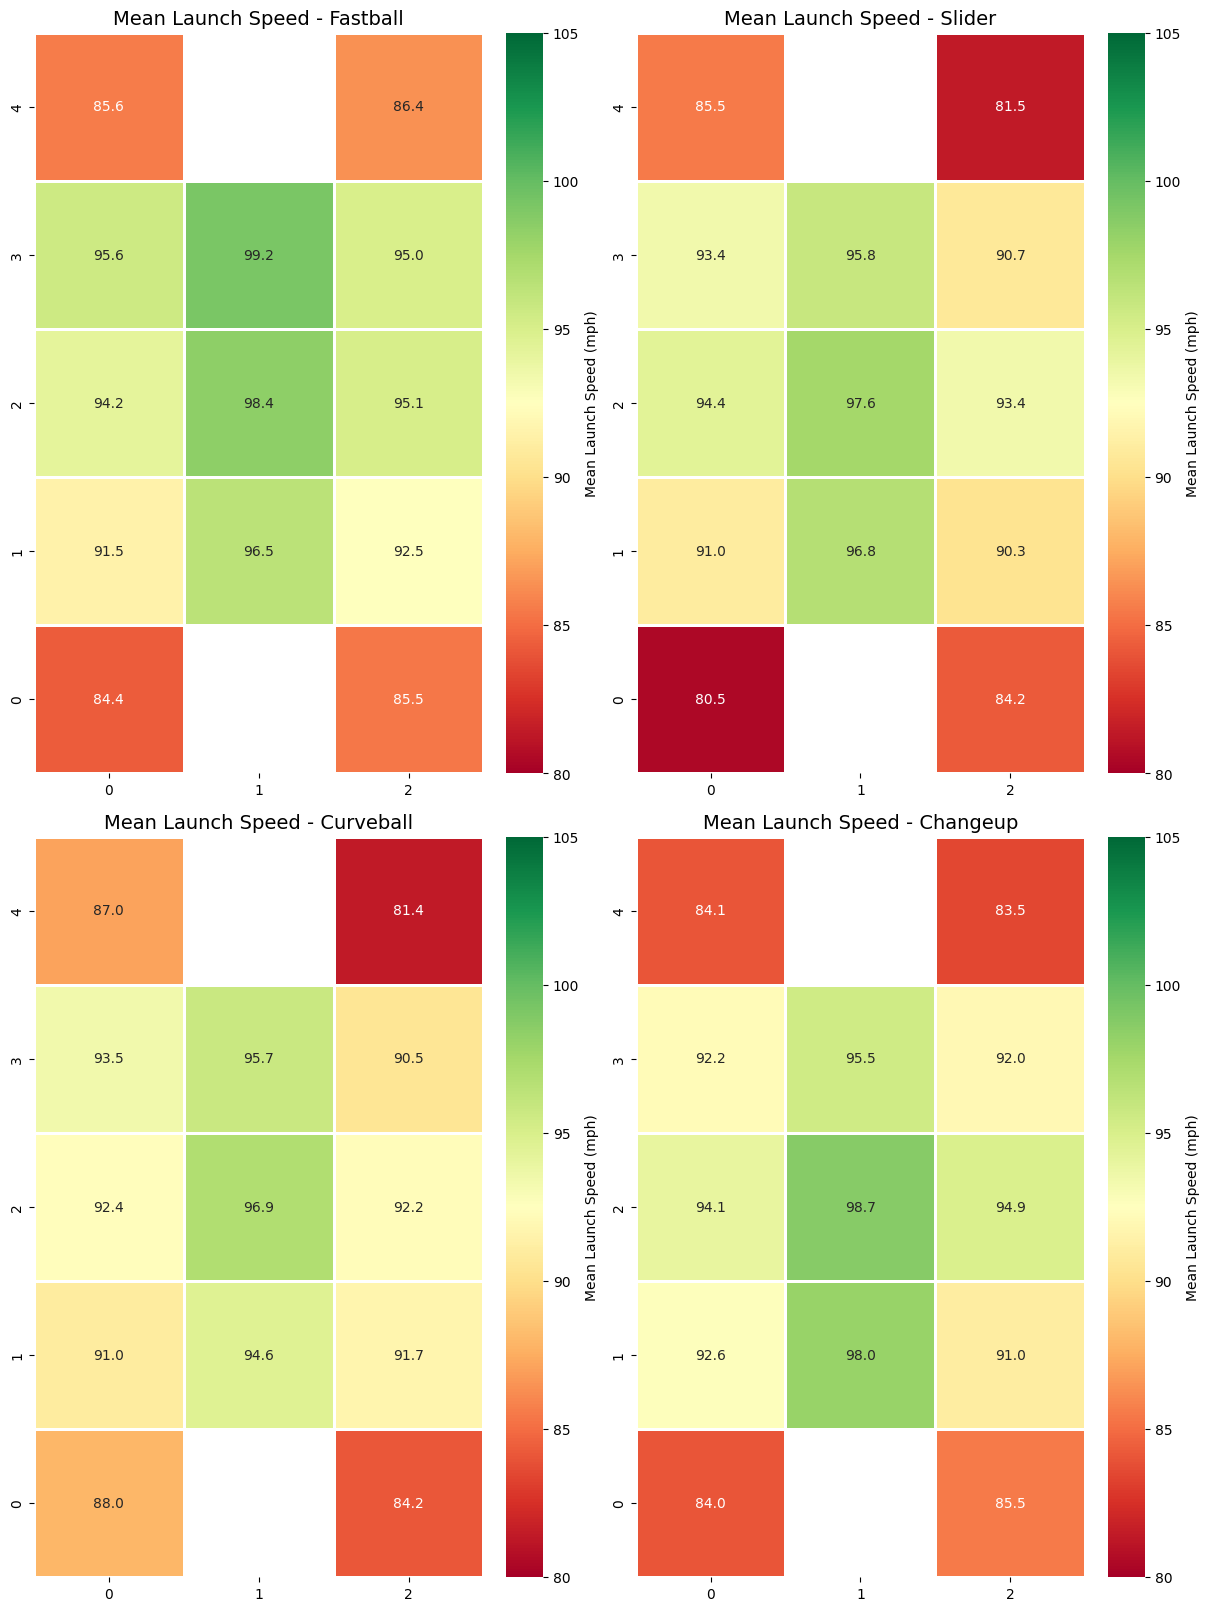

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Your zone layout grid (same as before)
zone_grid = pd.DataFrame([
    [11, None, 12],
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9],
    [13, None, 14]
])

# List of pitch groups you want to plot
pitch_groups = ['Fastball', 'Slider', 'Curveball', 'Changeup']

# Optional: you can specify a subset if you want (e.g., main pitch groups)
# pitch_groups = ['Fastball', 'Slider', 'Curveball', 'Changeup']

# Set up plot grid size (adjust as needed)
n = len(pitch_groups)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*8), constrained_layout=True)

for ax, pg in zip(axes.flatten(), pitch_groups):
    # Filter for this pitch_group
    subset = df_hits[df_hits['pitch_group'] == pg]
    
    # Compute mean launch speed by zone
    df_zone = (
        subset.groupby('zone')['launch_speed']
        .mean()
        .reset_index()
    )
    
    # Map mean launch speed to the strike zone grid
    heatmap_values = zone_grid.replace(
        {z: df_zone.set_index('zone')['launch_speed'].get(z) for z in df_zone['zone']}
    )
    
    sns.heatmap(
        heatmap_values.astype(float),
        annot=True, fmt=".1f", cmap="RdYlGn",
        linewidths=1, cbar_kws={'label': 'Mean Launch Speed (mph)'},
        vmin=80, vmax=105,
        ax=ax
    )
    ax.set_title(f'Mean Launch Speed - {pg}', fontsize=14)
    ax.invert_yaxis()

# If you have empty subplots, remove them
for ax in axes.flatten()[n:]:
    fig.delaxes(ax)

plt.show()


### Setting up DF Top 100 batters all pitches

In [12]:
import pandas as pd

# Load data
pitch_df = pd.read_csv('/workspaces/final-project-abshire/data/pitch_2024_top100_reduced.csv')
player_ids_df = pd.read_csv('/workspaces/final-project-abshire/data/player_ids.csv')

# Prepare player IDs
player_ids_sub = player_ids_df[['MLBAMID', 'Name']].rename(columns={'Name': 'batter_name'})

# Merge on batter and MLBAMID
df_top100 = pitch_df.merge(player_ids_sub, left_on='batter', right_on='MLBAMID', how='left')
df_top100 = df_top100.drop(columns=['MLBAMID'])
df_top100 = df_top100.rename(columns={'player_name': 'pitcher_name'})

# Filter to hitting events only
hitting_events = ['single', 'double', 'triple', 'home_run']
df_hits = df_top100[df_top100['events'].isin(hitting_events)].copy()

# Now define your pitch_type_map
pitch_type_map = {
    'FF': 'Fastball',  # Four-Seam
    'FA': 'Fastball',  # General Fastball
    'FT': 'Fastball',  # Two-Seam
    'SI': 'Fastball',  # Sinker
    'FS': 'Fastball',  # Split Finger
    'SL': 'Slider',    # Slider
    'SV': 'Slider',    # Slurve
    'ST': 'Curveball', # Sweeper
    'CU': 'Curveball', # Curveball
    'KC': 'Curveball', # Knuckle Curve
    'CH': 'Changeup',  # Change Up
    'FO': 'Changeup',  # Fork Ball
    'EP': 'Changeup',  # Eephus
    'FC': 'Fastball',  # Cutter
    'KN': 'Knuckleball', # Knuckleball
    'SC': 'Other',     # Screwball
    'CS': 'Other',     # Slow Curve
    'PO': 'Other',     # Pitch Out?
    None: 'Unknown',   # or np.nan mapped to 'Unknown'
    'NaN': 'Unknown'   # if string 'NaN'
}

# Map pitch_type to pitch_group column
df_top100['pitch_group'] = df_top100['pitch_type'].map(pitch_type_map).fillna('Unknown')

print(df_top100.head())

   Unnamed: 0  batter    pitcher_name   game_date stand p_throws pitch_type  \
0           0  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
1           1  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
2           2  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
3           3  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
4           4  572233  Vodnik, Victor  2024-03-31     R        R         SL   

   effective_speed  pfx_x  pfx_z  ...  zone    description  launch_speed  \
0             96.9  -1.01   1.16  ...   4.0  called_strike           NaN   
1             97.0  -0.86   1.12  ...  11.0           ball           NaN   
2             96.9  -0.84   1.11  ...  14.0      foul_bunt           NaN   
3             96.4  -0.97   1.14  ...   8.0       foul_tip           NaN   
4             85.5   0.33  -0.22  ...  14.0  called_strike           NaN   

  launch_angle  hc_x  hc_y  if_fielding_alignment     events  \
0   

## Setting Up DataFrames for Top 100 Batters

We are organizing our datasets for the Top 100 hitters into three main DataFrames:

- **`df_top100`** – Contains **all pitches** for the Top 100 batters.
- **`df_bip_top100`** – Contains **all balls in play (BIP)** for the Top 100 batters.
- **`df_hits_top100`** – Contains **all confirmed hits** for the Top 100 batters.


In [13]:
import pandas as pd

# Load data
bip_df = pd.read_csv('/workspaces/final-project-abshire/data/BIP_2024_top100.csv')
player_ids_df = pd.read_csv('/workspaces/final-project-abshire/data/player_ids.csv')

# Prepare player IDs
player_ids_sub = player_ids_df[['MLBAMID', 'Name']].rename(columns={'Name': 'batter_name'})

# Merge on batter and MLBAMID
df_bip_top100 = bip_df.merge(player_ids_sub, left_on='batter', right_on='MLBAMID', how='left')
df_bip_top100 = df_bip_top100.drop(columns=['MLBAMID'])

# Filter to hitting events only (adjust based on your BIP dataset columns)
hitting_events = ['single', 'double', 'triple', 'home_run']
df_hits_top100 = df_bip_top100[df_bip_top100['events'].isin(hitting_events)].copy()

# Map pitch_type to pitch_group column
pitch_type_map = {
    'FF': 'Fastball', 'FA': 'Fastball', 'FT': 'Fastball', 'SI': 'Fastball', 'FS': 'Fastball',
    'SL': 'Slider', 'SV': 'Slider', 'ST': 'Curveball', 'CU': 'Curveball', 'KC': 'Curveball',
    'CH': 'Changeup', 'FO': 'Changeup', 'EP': 'Changeup', 'FC': 'Fastball', 'KN': 'Knuckleball',
    'SC': 'Other', 'CS': 'Other', 'PO': 'Other', None: 'Unknown', 'NaN': 'Unknown'
}

df_bip_top100['pitch_group'] = df_bip_top100['pitch_type'].map(pitch_type_map).fillna('Unknown')
df_hits_top100['pitch_group'] = df_hits_top100['pitch_type'].map(pitch_type_map).fillna('Unknown')


In [14]:
# Quick check
print(df_top100.head())

   Unnamed: 0  batter    pitcher_name   game_date stand p_throws pitch_type  \
0           0  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
1           1  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
2           2  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
3           3  641857   Ginkel, Kevin  2024-03-31     L        R         FF   
4           4  572233  Vodnik, Victor  2024-03-31     R        R         SL   

   effective_speed  pfx_x  pfx_z  ...  zone    description  launch_speed  \
0             96.9  -1.01   1.16  ...   4.0  called_strike           NaN   
1             97.0  -0.86   1.12  ...  11.0           ball           NaN   
2             96.9  -0.84   1.11  ...  14.0      foul_bunt           NaN   
3             96.4  -0.97   1.14  ...   8.0       foul_tip           NaN   
4             85.5   0.33  -0.22  ...  14.0  called_strike           NaN   

  launch_angle  hc_x  hc_y  if_fielding_alignment     events  \
0   

### Need to make some features / new columns

In [15]:
df_top100["is_same_hit_pitch"] = (df_top100["stand"] == df_top100["p_throws"]).astype(int)
df_top100["is_single"] = (df_top100["events"] == "single").astype(int)
df_top100["is_double"] = (df_top100["events"] == "double").astype(int)
df_top100["is_triple"] = (df_top100["events"] == "triple").astype(int)
df_top100["is_home_run"] = (df_top100["events"] == "home_run").astype(int)
df_top100 = pd.get_dummies(df_top100, columns=['description'], prefix='desc')
print(df_top100.columns)

Index(['Unnamed: 0', 'batter', 'pitcher_name', 'game_date', 'stand',
       'p_throws', 'pitch_type', 'effective_speed', 'pfx_x', 'pfx_z',
       'plate_x', 'plate_z', 'zone', 'launch_speed', 'launch_angle', 'hc_x',
       'hc_y', 'if_fielding_alignment', 'events', 'batter_name', 'pitch_group',
       'is_same_hit_pitch', 'is_single', 'is_double', 'is_triple',
       'is_home_run', 'desc_ball', 'desc_blocked_ball', 'desc_bunt_foul_tip',
       'desc_called_strike', 'desc_foul', 'desc_foul_bunt', 'desc_foul_tip',
       'desc_hit_by_pitch', 'desc_hit_into_play', 'desc_missed_bunt',
       'desc_pitchout', 'desc_swinging_strike',
       'desc_swinging_strike_blocked'],
      dtype='object')


### Making refined DF for modeling

In [16]:
# Define the columns to keep
columns_to_keep = [
    'pitcher_name', 'stand', 'p_throws', 'effective_speed',
    'pfx_x', 'pfx_z', 'plate_x', 'plate_z', 'zone', 'launch_speed',
    'launch_angle', 'hc_x', 'hc_y', 'events', 'batter_name', 'pitch_group',
    'is_same_hit_pitch', 'is_single', 'is_double', 'is_triple', 'is_home_run',
    'desc_foul', 'desc_hit_into_play', 'desc_swinging_strike', 'desc_swinging_strike_blocked'
]

# Create refined DataFrame
df_top100_refined = df_top100[columns_to_keep].copy()
df_top100_refined['is_hit'] = df_top100_refined[['is_single','is_double','is_triple','is_home_run']].max(axis=1)


# Preview
print(df_top100_refined.head())


     pitcher_name stand p_throws  effective_speed  pfx_x  pfx_z  plate_x  \
0   Ginkel, Kevin     L        R             96.9  -1.01   1.16    -0.73   
1   Ginkel, Kevin     L        R             97.0  -0.86   1.12    -0.49   
2   Ginkel, Kevin     L        R             96.9  -0.84   1.11     1.01   
3   Ginkel, Kevin     L        R             96.4  -0.97   1.14     0.19   
4  Vodnik, Victor     R        R             85.5   0.33  -0.22     0.89   

   plate_z  zone  launch_speed  ...  is_same_hit_pitch  is_single  is_double  \
0     2.25   4.0           NaN  ...                  0          0          0   
1     4.40  11.0           NaN  ...                  0          0          0   
2     2.35  14.0           NaN  ...                  0          0          0   
3     2.11   8.0           NaN  ...                  0          0          0   
4     1.92  14.0           NaN  ...                  1          0          0   

  is_triple is_home_run desc_foul  desc_hit_into_play  desc_sw

### Start Modeling

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.88      0.85      4252
           1       0.75      0.66      0.70      2275

    accuracy                           0.80      6527
   macro avg       0.79      0.77      0.78      6527
weighted avg       0.80      0.80      0.80      6527

ROC AUC Score: 0.8605127515945954

Top 10 Important Features:
              feature  importance
8       launch_angle    0.280981
7       launch_speed    0.212495
0    effective_speed    0.086560
1              pfx_x    0.086249
2              pfx_z    0.086008
4            plate_z    0.085883
3            plate_x    0.084925
5               zone    0.032631
9            stand_R    0.010265
6  is_same_hit_pitch    0.009954


/tmp/ipykernel_5094/640189026.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


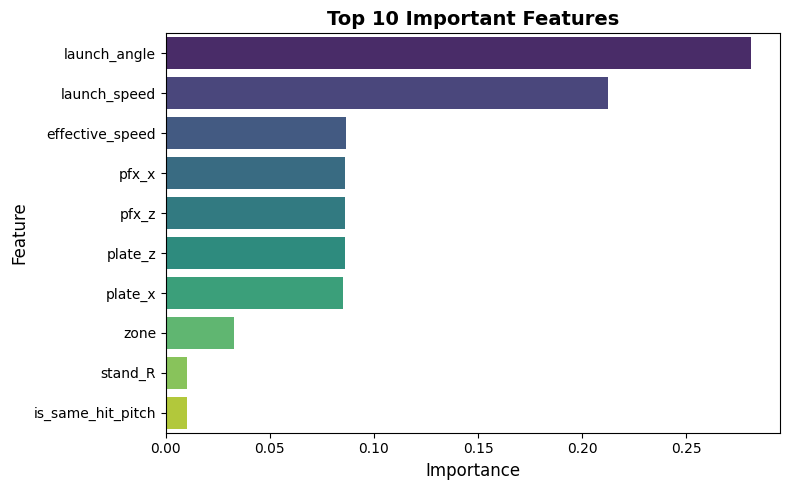

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ------------------------------
# 1. Filter to balls in play (contact quality)
# ------------------------------
df_bip_top100 = df_top100_refined[df_top100_refined['desc_hit_into_play'] == 1].copy()

# ------------------------------
# 2. Define features and target
# ------------------------------
y_hit = df_bip_top100['is_hit']

features = [
    'stand', 'p_throws', 'pitch_group',
    'effective_speed', 'pfx_x', 'pfx_z',
    'plate_x', 'plate_z', 'zone',
    'is_same_hit_pitch', 'launch_speed', 'launch_angle'
]

X_hit = df_bip_top100[features]

# ------------------------------
# 3. One-hot encode categorical features
# ------------------------------
X_hit_encoded = pd.get_dummies(
    X_hit, 
    columns=['stand', 'p_throws', 'pitch_group'], 
    drop_first=True
)

# ------------------------------
# 4. Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_hit_encoded, y_hit, test_size=0.2, random_state=42, stratify=y_hit
)

# ------------------------------
# 5. Train Random Forest model
# ------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ------------------------------
# 6. Make predictions and evaluate
# ------------------------------
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

# ------------------------------
# 7. Feature importance
# ------------------------------
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print("\nTop 10 Important Features:\n", feature_importance_df.head(10))

# ------------------------------
# 8. Visualization of top features
# ------------------------------
top_features = feature_importance_df.head(10)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=top_features,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Top 10 Important Features", fontsize=14, weight="bold")
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

### Retrain model on 2 swing features and 3 pitch features

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.87      0.84      4252
           1       0.72      0.64      0.68      2275

    accuracy                           0.79      6527
   macro avg       0.77      0.76      0.76      6527
weighted avg       0.79      0.79      0.79      6527

ROC AUC Score: 0.8566956984689816


/tmp/ipykernel_5094/166492837.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


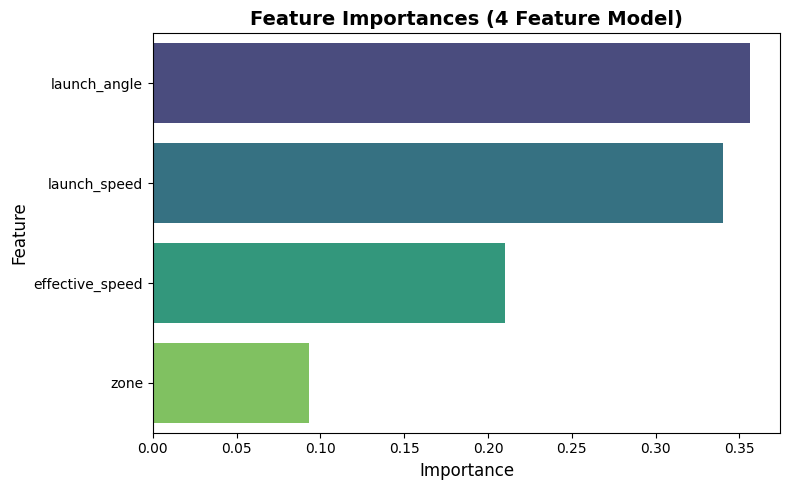

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# ------------------------------
# 1. Filter to balls in play (contact quality)
# ------------------------------
df_bip_top100 = df_top100_refined[df_top100_refined['desc_hit_into_play'] == 1].copy()

# ------------------------------
# 2. Select features (numeric only)
# ------------------------------
features = ['launch_angle', 'launch_speed', 'effective_speed', 'zone']
X_hit = df_bip_top100[features]
y_hit = df_bip_top100['is_hit']

# ------------------------------
# 3. Train/test split
# ------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_hit, y_hit, test_size=0.2, random_state=42, stratify=y_hit
)

# ------------------------------
# 4. Train Random Forest model
# ------------------------------
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ------------------------------
# 5. Evaluate
# ------------------------------
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba))

# ------------------------------
# 6. Feature importance visualization
# ------------------------------
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=feature_importance_df,
    x="importance",
    y="feature",
    palette="viridis"
)
plt.title("Feature Importances (4 Feature Model)", fontsize=14, weight="bold")
plt.xlabel("Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()

# ------------------------------
# 7. Prediction function
# ------------------------------
def predict_hit(launch_angle, launch_speed, effective_speed, zone):
    new_pitch = pd.DataFrame([{
        'launch_angle': launch_angle,
        'launch_speed': launch_speed,
        'effective_speed': effective_speed,
        'zone': zone
    }])
    
    pred_class = rf_model.predict(new_pitch)[0]
    pred_prob = rf_model.predict_proba(new_pitch)[0][1]
    
    return {
        'predicted_class': int(pred_class),
        'prediction_label': 'Hit' if pred_class == 1 else 'Not Hit',
        'hit_probability': round(pred_prob, 3)
    }


In [19]:
# ------------------------------
# 8. Example prediction
# ------------------------------
example_result = predict_hit(
    launch_angle=26,
    launch_speed=45.3,
    effective_speed=98.2,
    zone=14
)
print(example_result)

{'predicted_class': 0, 'prediction_label': 'Not Hit', 'hit_probability': np.float64(0.11)}


In [20]:
import ipywidgets as widgets

out = widgets.Output()

def predict_hit_ui(launch_angle, launch_speed, effective_speed, zone):
    with out:
        out.clear_output()
        new_pitch = pd.DataFrame([{
            'launch_angle': launch_angle,
            'launch_speed': launch_speed,
            'effective_speed': effective_speed,
            'zone': zone
        }])
        pred_class = rf_model.predict(new_pitch)[0]
        pred_prob = rf_model.predict_proba(new_pitch)[0][1]
        color = 'green' if pred_class == 1 else 'red'
        display(HTML(f"<h3 style='color:{color};'>{'Hit' if pred_class==1 else 'Not Hit'}</h3>"))
        display(HTML(f"<p>Probability: {pred_prob:.2f}</p>"))

interact(
    predict_hit_ui,
    launch_angle=FloatSlider(value=20.0, min=-30, max=50, step=0.5, description='Launch Angle'),
    launch_speed=FloatSlider(value=95.0, min=60, max=120, step=0.5, description='Launch Speed'),
    effective_speed=FloatSlider(value=90.0, min=60, max=110, step=0.5, description='Effective Speed'),
    zone=IntSlider(value=5, min=1, max=9, step=1, description='Zone')
)
display(out)


NameError: name 'interact' is not defined